Slope (w1): 3.031500600240096
Intercept (w0): 3.396734693877548
MSE: 2.353356062424966
RMSE: 1.5340652080094137


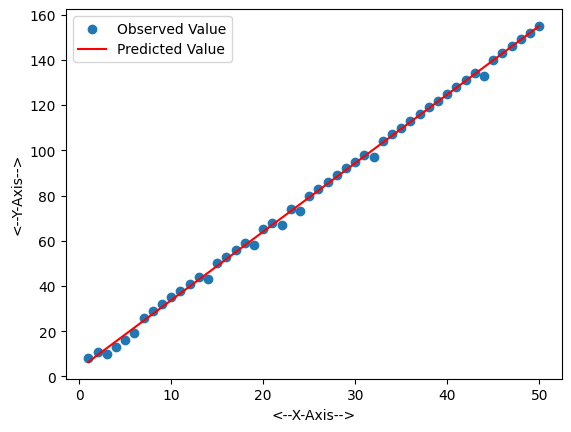

In [2]:
from math import sqrt
import numpy as np
import matplotlib.pyplot as plt


def rmse_metric(actual, predicted):
    sum_error = 0.0
    for y, y_hat in zip(actual, predicted):
        prediction_error = y - y_hat
        sum_error += (prediction_error ** 2)
    mean_error = sum_error / float(len(actual))
    return sqrt(mean_error)


def compute_coefficient(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator = 0
    denominator = 0

    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean)
        denominator += (x[i] - x_mean) ** 2

    # Calculate coefficients
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean

    return slope, intercept


def predict(x, w1, w0):
    return w1 * x + w0


def evaluate_ols(y, y_hat):
    mse = np.mean((y - y_hat) ** 2)
    return mse, np.sqrt(mse)


# Create toy dataset: x from 1 to 50, y = 3x + 5 with random noise
x = np.arange(1, 51)
y = x * 3 + 5

# Add random error at 10 random indices
y[np.random.randint(0, len(y), size=10)] += np.random.randint(-5, 5)

# Compute coefficients and predict
w1, w0 = compute_coefficient(x, y)
y_hat = predict(x, w1, w0)

# Display predicted coefficients
print(f"Slope (w1): {w1}")
print(f"Intercept (w0): {w0}")

# Evaluate using MSE and RMSE
mse, rmse = evaluate_ols(y, y_hat)
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

# Plot observed vs predicted values
plt.scatter(x, y, label='Observed Value')
plt.plot(x, y_hat, label='Predicted Value', color='red')
plt.xlabel('<--X-Axis-->')
plt.ylabel('<--Y-Axis-->')
plt.legend()
plt.show()
